In [1]:
import numpy as np
import pandas as pd
import hvplot.pandas
import matplotlib.pyplot as plt


In [11]:
k = 3
d = pd.read_hdf("output/meta-llama_Meta-Llama-3.1-8B-Instruct/d_r.h5")
rho = pd.read_hdf("output/meta-llama_Meta-Llama-3.1-8B-Instruct/rho_d.h5")
s = d - rho - np.log(k)

In [12]:
all_s = s.to_numpy()
mean_s = np.mean(all_s, axis=1)
std_s = np.std(all_s, axis=1)

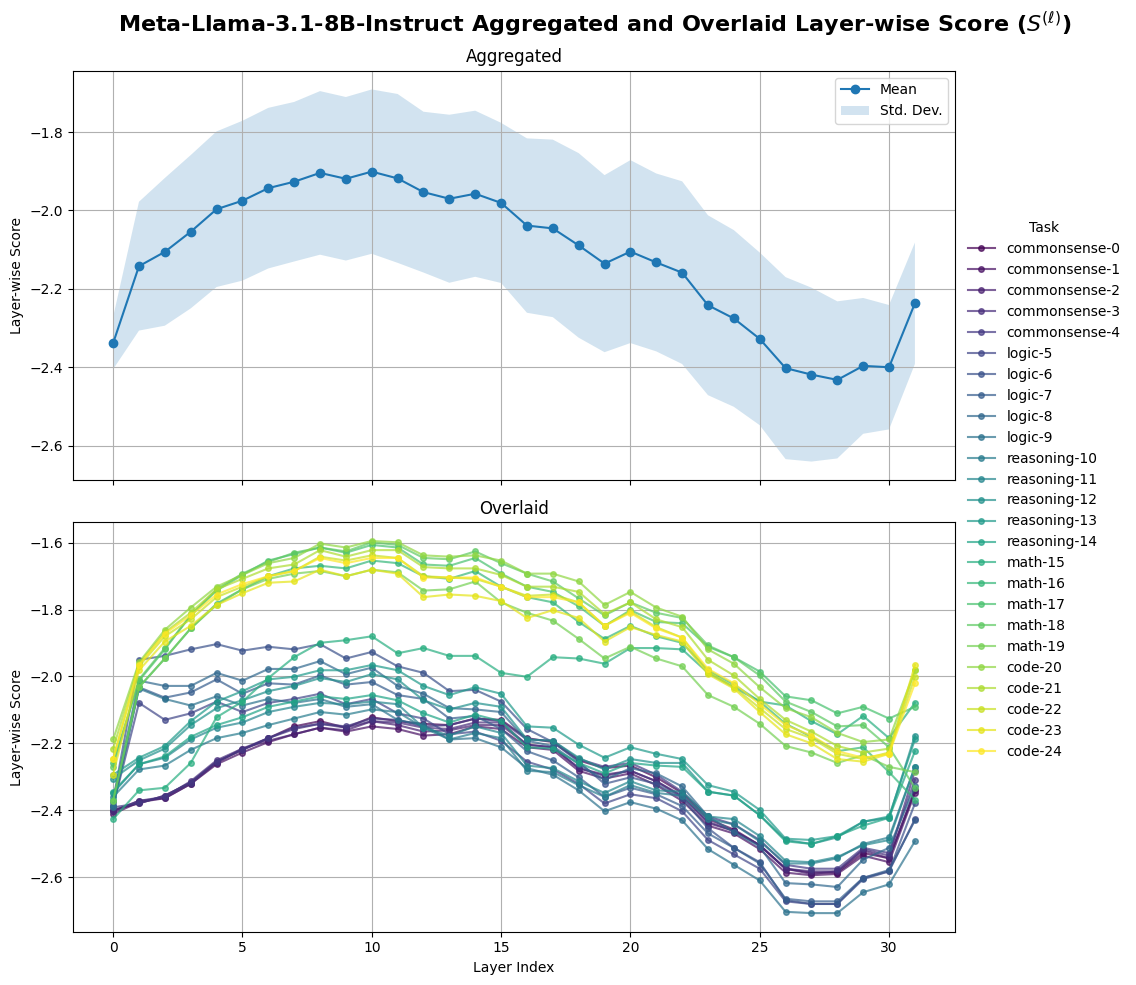

In [13]:
layer_indices = list(range(len(mean_s)))

fig, (agg, ov) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
agg.plot(layer_indices, mean_s, marker="o", linestyle="-", label="Mean")
agg.fill_between(
    layer_indices,
    mean_s - std_s,
    mean_s + std_s,
    alpha=0.2,
    label="Std. Dev.",
)

colors = plt.cm.viridis(np.linspace(0, 1, len(all_s[0])))

legend_handles = []
for color, (task_name, scores) in enumerate(s.to_dict().items()):
    layerwise_scores = np.array([v for v in scores.values()])
    (line1,) = ov.plot(
        layer_indices,
        layerwise_scores,
        marker="o",
        markersize=4,
        linestyle="-",
        alpha=0.7,
        color=colors[color],
        label=task_name,
    )
    legend_handles.append(line1)

agg.set_title("Aggregated")
agg.set_ylabel("Layer-wise Score")
agg.legend()
agg.grid(True)

ov.set_title("Overlaid")
ov.set_xlabel("Layer Index")
ov.set_ylabel("Layer-wise Score")
ov.grid(True)

fig.suptitle("Meta-Llama-3.1-8B-Instruct Aggregated and Overlaid Layer-wise Score ($S^{(\\ell)}$)", fontsize=16, fontweight='bold')
fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.8, 0.5),
    title="Task",
    frameon=False,
)
fig.tight_layout()
plt.subplots_adjust(right=0.8)
plt.show()
fig.savefig("output/score.pdf", bbox_inches="tight")


In [29]:
# s.to_numpy().shape
# # for each column (task) find max layer s
smax = s.max(axis=0)
# smax.shape
display(smax.mean(), smax.std())

np.float64(-1.8957997886681097)

np.float64(0.21127155743217718)

In [31]:
L, _ = s.shape
ausn = 1/L * s.sum()
display(ausn.mean(), ausn.std())

np.float64(-2.11938865585561)

np.float64(0.19754994553075475)

In [36]:
lmax = np.argmax(s, axis=0)

display(np.median(lmax), np.percentile(s, 75) - np.percentile(s, 25))

np.float64(10.0)

np.float64(0.3837890625000002)